# Lag-0 Cross-Correlation Heatmap

Prototype for replacing the faceted CCF grid (`results-ccf` chunk in `ThesisDraft_v2.Rmd`).

- Lag-0 cross-correlation = Pearson correlation of the two region residual series.
- Lower-triangle heatmap of the 6 HSE regions.
- Significance band: `1.96 / sqrt(n)` ~ 0.15 for n = 170.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

CSV = "../data/models/wide_weekly_scaledPer10k/v4.6/residuals_posterior_mean.csv"
res = pd.read_csv(CSV)

abbr = {
    "HSE Dublin and Midlands": "DML",
    "HSE Dublin and North East": "DNE",
    "HSE Dublin and South East": "DSE",
    "HSE Mid West": "MW",
    "HSE South West": "SW",
    "HSE West and North West": "WNW",
}
res = res.rename(columns=abbr)
n = len(res)
band = 1.96 / np.sqrt(n)
print("n =", n, " band =", round(band, 3))

n = 170  band = 0.15


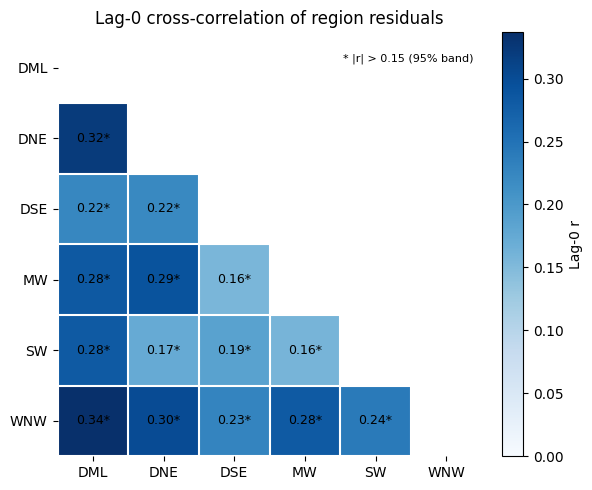

min |r| = 0.156


In [2]:
C = res.corr()
labels = list(res.columns)
k = len(labels)

# lower triangle only (row > col), upper + diagonal masked
M = np.full((k, k), np.nan)
for i in range(k):
    for j in range(i):
        M[i, j] = C.iloc[i, j]

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(M, cmap="Blues", vmin=0, vmax=np.nanmax(M))

# value in each cell; trailing * marks correlations above the significance band
for i in range(k):
    for j in range(i):
        star = "*" if abs(M[i, j]) > band else ""
        ax.text(j, i, f"{M[i, j]:.2f}{star}", ha="center", va="center", fontsize=9)

ax.set_xticks(range(k)); ax.set_xticklabels(labels)
ax.set_yticks(range(k)); ax.set_yticklabels(labels)
ax.set_xticks(np.arange(-.5, k, 1), minor=True)
ax.set_yticks(np.arange(-.5, k, 1), minor=True)
ax.grid(which="minor", color="white", linewidth=1.5)
ax.tick_params(which="minor", length=0)
for s in ax.spines.values():
    s.set_visible(False)

cb = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="Lag-0 r")
ax.set_title("Lag-0 cross-correlation of region residuals")
ax.text(0.98, 0.95, f"* |r| > {band:.2f} (95% band)",
        transform=ax.transAxes, ha="right", va="top", fontsize=8)
fig.tight_layout()
fig.savefig("lag0_corr_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("min |r| =", round(np.nanmin(np.abs(M)), 3))